# Classification #

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
import logging
import os

# Increase font size of all Seaborn plot elements
sns.set(font_scale = 1.25)

# Set Seaborn theme
sns.set_theme(style = "white")

# Suppress tensorflow messages and progress bars 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  

In [4]:
data = pd.read_csv("Dataset of Diabetes.csv")

In [5]:
data.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,NaN,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


### Assignment 1: Exploratory Data Analysis (30 points) ###
1. Display the basic description of the dataset, including its shape, columns, and data types.
2. Drop the 'ID', 'No_Pation' column.
3. Replace missing values in 'CLASS' with 'P'
4. Boxplot to visualize relationships between 'HbA1c' and 'Gender'
5. Scatterplot to visualize relationship between 'Age' and 'Urea' with different 'CLASS'
6. Countplot to visualize 'Gender' distribution with different 'CLASS'
7. Choose and visualize some relationships

In [6]:
# 1. Display the basic description of the dataset, including its shape, columns, and data types.
print("1. Dataset Shape:", data.shape)
print("\n2. Column Names:", data.columns.tolist())
print("\n3. Data Types:\n", data.dtypes)

1. Dataset Shape: (1000, 14)

2. Column Names: ['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']

3. Data Types:
 ID             int64
No_Pation      int64
Gender           str
AGE            int64
Urea         float64
Cr             int64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS            str
dtype: object


In [8]:
# 2. Drop the 'ID', 'No_Pation' column.
data.drop(['ID', 'No_Pation'], axis=1, inplace=True, errors='ignore')

In [12]:
# 3. Replace missing values in 'CLASS' with 'P'
data['CLASS'] = data['CLASS'].str.strip()
data['CLASS'] = data['CLASS'].fillna('P')


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8464\2030490733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='HbA1c', data=data, palette='Set2')


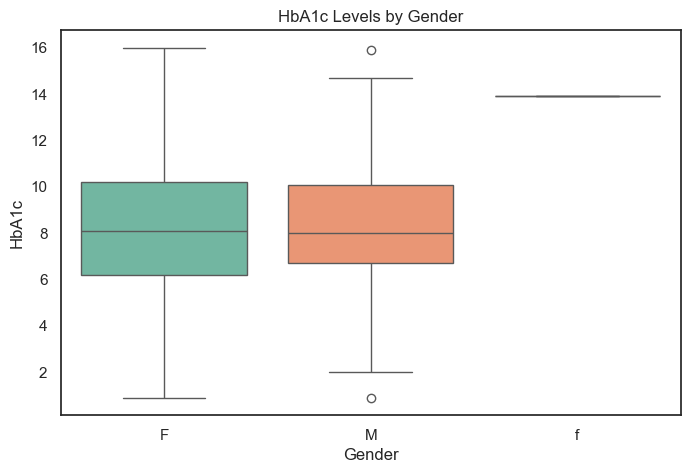

In [13]:
# 4. Boxplot to visualize relationships between 'HbA1c' and 'Gender'
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='HbA1c', data=data, palette='Set2')
plt.title('HbA1c Levels by Gender')
plt.show()

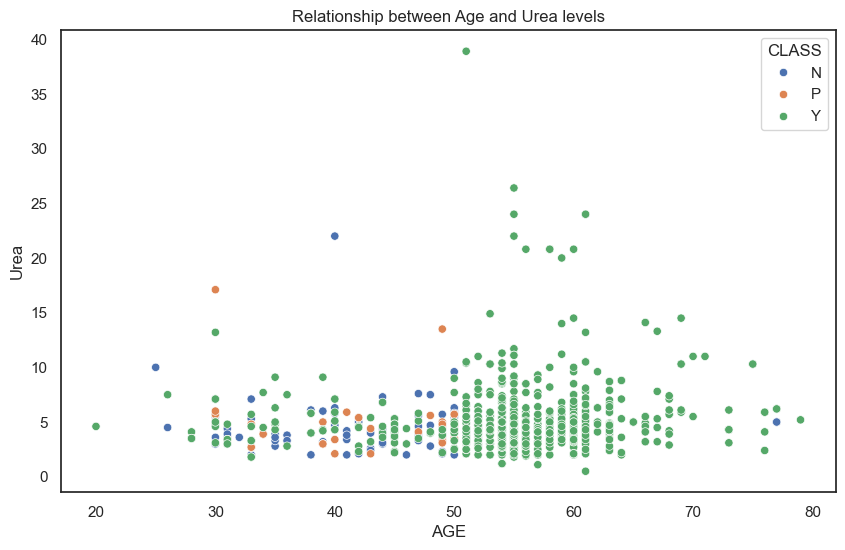

In [14]:
# 5. Scatterplot to visualize relationship between 'Age' and 'Urea' with different 'CLASS'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AGE', y='Urea', hue='CLASS', data=data)
plt.title('Relationship between Age and Urea levels')
plt.show()

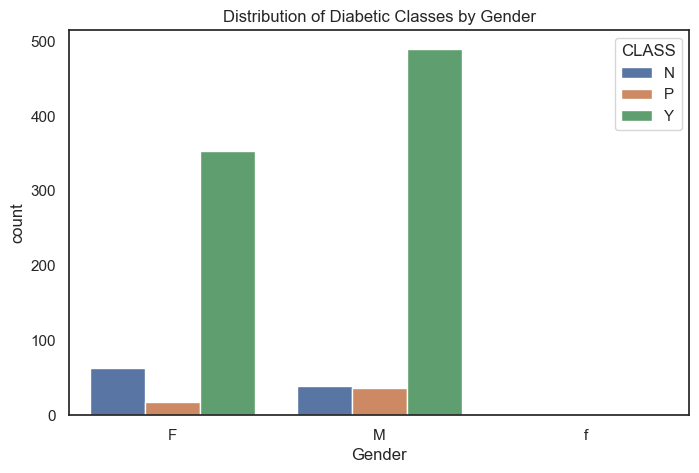

In [15]:
# 6. Countplot to visualize 'Gender' distribution with different 'CLASS'
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='CLASS', data=data)
plt.title('Distribution of Diabetic Classes by Gender')
plt.show()

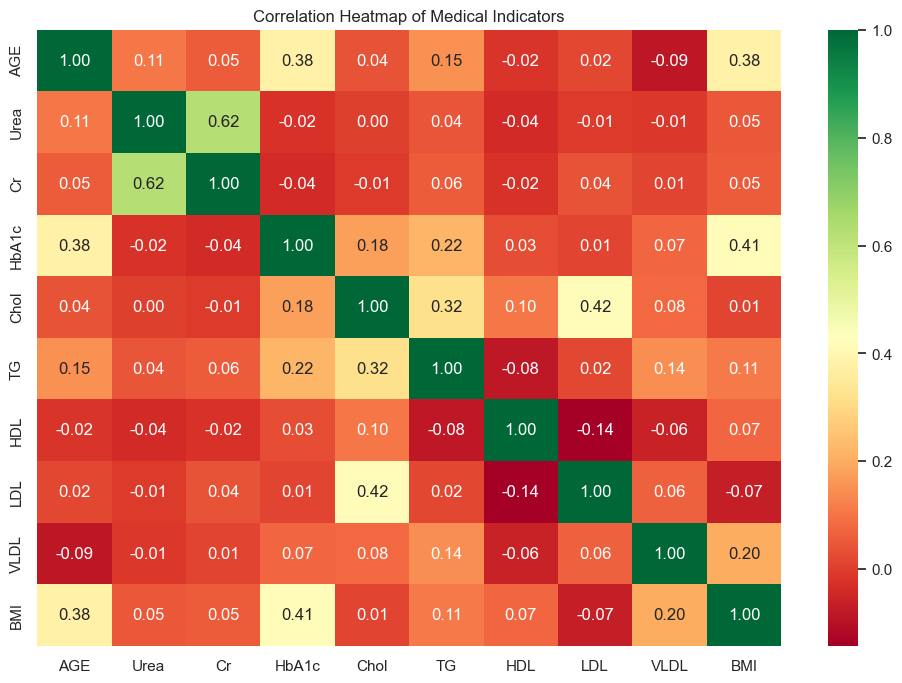

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8464\2159415750.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='CLASS', y='BMI', data=data, ci=None)


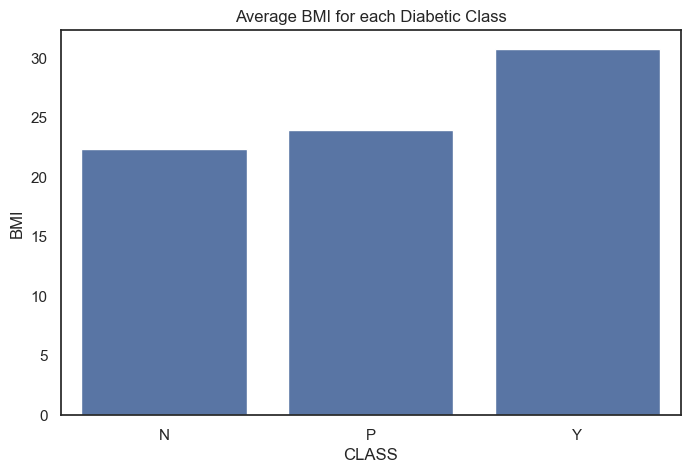

In [16]:
# 7. Choose and visualize some relationships
# Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_cols = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Heatmap of Medical Indicators')
plt.show()

#BMI vs CLASS
plt.figure(figsize=(8, 5))
sns.barplot(x='CLASS', y='BMI', data=data, ci=None)
plt.title('Average BMI for each Diabetic Class')
plt.show()

### Assignment  2: Data Cleaning (20 points) ###
Identifying missing values and remove or impute where appropriate.

In [ ]:
# 1. Remove spaces and convert to uppercase
data['Gender'] = data['Gender'].str.upper().str.strip()
data['CLASS'] = data['CLASS'].str.upper().str.strip()

# 2. Check missing values before cleaning
print("Missing values before cleaning:")
print(data.isnull().sum())

# 3. Handle missing values for categorical column 'CLASS'
# Replacing NaN with 'P' as requested
data['CLASS'] = data['CLASS'].fillna('P')

# 4. Handle missing values for numerical columns (HbA1c and VLDL)
# Using Median Imputation
data['HbA1c'] = data['HbA1c'].fillna(data['HbA1c'].median())
data['VLDL'] = data['VLDL'].fillna(data['VLDL'].median())

# 5. Final verification
print("\nMissing values after cleaning:")
print(data.isnull().sum())

# Check unique values to ensure consistency
print("\nUnique Gender values:", data['Gender'].unique())
print("Unique CLASS values:", data['CLASS'].unique())

Missing values before cleaning:
Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     1
Chol      0
TG        0
HDL       0
LDL       0
VLDL      1
BMI       0
CLASS     0
dtype: int64

Missing values after cleaning:
Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64

Unique Gender values: <StringArray>
['F', 'M']
Length: 2, dtype: str
Unique CLASS values: <StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str


### Assignment  3: Correlations (20 points) ###
1. Identifying highly correlated numeric columns (threashold is 0.6)
2. Choose and drop some columns in highly correlated pairs.

In [18]:
# 1. Identify highly correlated numeric columns
corr_matrix = data.select_dtypes(include=[np.number]).corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.6
high_corr_cols = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"Columns to be dropped due to high correlation (> {threshold}): {high_corr_cols}")

# 2. Drop the highly correlated columns
data.drop(columns=high_corr_cols, inplace=True)

print("\nRemaining columns after dropping high correlation pairs:")
print(data.columns.tolist())

Columns to be dropped due to high correlation (> 0.6): ['Cr']

Remaining columns after dropping high correlation pairs:
['Gender', 'AGE', 'Urea', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']


### Assignment  4: Classfication (30 points) ###
1. Convert 'CLASS' to categorial data and reorder as specified in ['N', 'P', 'Y']
2. Convert categorical data to numerical data using label encoding.
3. Define features, target
4. Normalize or standardize features
5. Split the dataset into training (80%) and testing (20%) sets.
6. Reduce dimensionality using PCA
7. Train logistic regression model, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary. 
8. Train K-nearest neighbors classfifier, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary. 
9. Train naive Bayes model, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary. 
10. Train decision tree classifier, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary.
11. Train random forest classifier, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary.
12. Train AdaBoost classifier, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary.

In [19]:
# 1. Convert 'CLASS' to categorical and reorder as ['N', 'P', 'Y']
data['CLASS'] = pd.Categorical(data['CLASS'], categories=['N', 'P', 'Y'], ordered=True)

In [20]:
# 2. Convert categorical data to numerical data using label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
data['CLASS'] = data['CLASS'].cat.codes

In [21]:
# 3. Define features and target
X = data.drop('CLASS', axis=1)
y = data['CLASS']

In [22]:
# 4. Normalize or standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# 5. Split the dataset into training (80%) and testing (20%) sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [38]:
# 6. Reduce dimensionality using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

def run_model(model, name):
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

def run_model(model, name):
    # Train the model on PCA components
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    
    # Calculate Metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # --- DISPLAY DECISION BOUNDARY ---
    h = .02  # step size in the mesh
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict over the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap='viridis', s=30)
    plt.title(f"Decision Boundary: {name} (via PCA)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

In [ ]:
# 7. Train logistic regression model, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary. 
from sklearn.linear_model import LogisticRegression
run_model(LogisticRegression(), "Logistic Regression")


--- Logistic Regression Results ---
Accuracy: 0.9300
Precision: 0.9174
Recall: 0.9300
F1 Score: 0.9205
Confusion Matrix:
 [[ 20   0   1]
 [  4   0   2]
 [  7   0 166]]


c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# 8. Train K-nearest neighbors classfifier, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary. 

from sklearn.neighbors import KNeighborsClassifier
run_model(KNeighborsClassifier(), "K-Nearest Neighbors")


--- K-Nearest Neighbors Results ---
Accuracy: 0.9250
Precision: 0.9384
Recall: 0.9250
F1 Score: 0.9310
Confusion Matrix:
 [[ 18   2   1]
 [  2   2   2]
 [  3   5 165]]


In [ ]:
# 9. Train naive Bayes model, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary. 

from sklearn.naive_bayes import GaussianNB
run_model(GaussianNB(), "Naive Bayes")


--- Naive Bayes Results ---
Accuracy: 0.9150
Precision: 0.9120
Recall: 0.9150
F1 Score: 0.9118
Confusion Matrix:
 [[ 18   1   2]
 [  4   0   2]
 [  6   2 165]]


In [ ]:
# 10. Train decision tree classifier, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary.

from sklearn.tree import DecisionTreeClassifier
run_model(DecisionTreeClassifier(max_depth=5), "Decision Tree")


--- Decision Tree Results ---
Accuracy: 0.9350
Precision: 0.9243
Recall: 0.9350
F1 Score: 0.9263
Confusion Matrix:
 [[ 15   0   6]
 [  2   1   3]
 [  1   1 171]]


In [ ]:
# 11. Train random forest classifier, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary.

from sklearn.ensemble import RandomForestClassifier
run_model(RandomForestClassifier(n_estimators=100), "Random Forest")


--- Random Forest Results ---
Accuracy: 0.9400
Precision: 0.9411
Recall: 0.9400
F1 Score: 0.9404
Confusion Matrix:
 [[ 16   1   4]
 [  1   4   1]
 [  3   2 168]]


In [ ]:
# 12. Train AdaBoost classifier, calculate the accuracy, precision, recall, f1 score, confusion matrix and display the decision boundary.
from sklearn.ensemble import AdaBoostClassifier
run_model(AdaBoostClassifier(n_estimators=50), "AdaBoost")


--- AdaBoost Results ---
Accuracy: 0.9350
Precision: 0.9370
Recall: 0.9350
F1 Score: 0.9309
Confusion Matrix:
 [[ 16   0   5]
 [  2   2   2]
 [  4   0 169]]
